# Startup Sales - EDA 

**Problem:** We have a messy, raw sales dataset (`messy_startup_sales.csv`) from a startup. It has inconsistent text formatting, wrong data types, invalid values, missing values, and duplicate rows so it can't be trusted for analysis yet.

**Approach:** First clean and standardize the data step by step, then explore it (EDA) to find patterns in revenue, customers, and products that can help the business make decisions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load the Dataset
Read the raw CSV file into a pandas DataFrame so we can start inspecting it.

In [2]:
df=pd.read_csv('messy_startup_sales.csv')

In [3]:
df.head()

,OrderID,CustomerID,CustomerName,Age,City,Email,Department,OrderDate,ProductCategory,PaymentMode,OrderStatus,UnitPrice,Quantity,DiscountPct,Revenue,Rating,IsReturningCustomer
0,ORD510665,CUST110665,Ananya Iyer,60.0,kolkata,ananya.iyer@gmail.com,NaN,2025-02-05,Electronics,upi,Pending,152.91,3.0,15,389.92,1.0,0
1,ORD513381,CUST113381,Pooja Gupta,39.0,BANGALORE,NaN,NaN,03-11-2023,Groceries,COD,Pending,115.33,3.0,0,345.99,3.0,no
2,ORD501844,101844.0,Sourav Trivedi,31.0,Gurgaon,sourav.trivedi@gmail.com,Finance,20-May-2025,Apparel,COD,CANCELLED,2109.53,1.0,5,2004.05,4.0,0
3,ORD501144,CUST101144,Anjali Pillai,55.0,Noida,anjali.pillai@yahoo.com,HR,"July 11, 2025",electronics,COD,Cancelled,₹357.1,1.0,5,339.24,2.0,False
4,ORD516008,CUST116008,Deepak Roy,33.0,BANGALORE,deepak.roy@gmail.com,Support,06-28-2022,Books,upi,Returned,773.26,3.0,0,2319.78,5.0,Yes


**What this shows:** A quick preview of the raw data. Already we can spot problems - `City` has mixed casing (`kolkata`, `BANGALORE`), `CustomerID` is sometimes a plain number instead of `CUST...`, `UnitPrice` has a `₹` symbol (so it's stored as text, not a number), and `IsReturningCustomer` mixes `0`, `no`, `False`, `Yes` for what should be one Yes/No field.

In [4]:
df.shape

(20400, 17)

**What this shows:** The dataset has **20,400 rows and 17 columns**.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OrderID              20400 non-null  str    
 1   CustomerID           20400 non-null  str    
 2   CustomerName         20400 non-null  str    
 3   Age                  19794 non-null  float64
 4   City                 20400 non-null  str    
 5   Email                19988 non-null  str    
 6   Department           6147 non-null   str    
 7   OrderDate            20400 non-null  str    
 8   ProductCategory      20400 non-null  str    
 9   PaymentMode          20400 non-null  str    
 10  OrderStatus          20400 non-null  str    
 11  UnitPrice            20400 non-null  str    
 12  Quantity             20227 non-null  float64
 13  DiscountPct          20400 non-null  str    
 14  Revenue              20400 non-null  float64
 15  Rating               18417 non-null  float64
 1

**What this shows:** Two problems jump out:
- **Wrong data types:** `UnitPrice` and `DiscountPct` are stored as text (`str`) instead of numbers, because of symbols like `₹` and `%`. `OrderDate` is also text instead of a date.
- **Missing values:** `Department` is missing in 14,253 of 20,400 rows (~70%!), `Rating` is missing in ~1,983 rows, and `Age`, `Email`, `Quantity` have smaller gaps too.

In [6]:
df.describe()

,Age,Quantity,Revenue,Rating
count,19794.000000,20227.000000,2.040000e+04,18417.000000
mean,41.104527,2.994710,8.182640e+03,3.908617
std,15.074404,1.420361,4.515602e+04,1.210008
min,-5.000000,1.000000,8.026000e+01,0.000000
25%,29.000000,2.000000,1.162233e+03,3.000000
50%,41.000000,3.000000,2.762365e+03,4.000000
75%,53.000000,4.000000,6.104497e+03,5.000000
max,150.000000,5.000000,1.769572e+06,8.000000


**What this shows:** Some values are clearly invalid:
- `Age` ranges from **-5 to 150** : humans can't be negative or 150 years old, so these are data entry errors.
- `Rating` goes up to **8**, but a rating scale should only be 1–5.
- `Revenue` has a huge gap between the average (₹8,182) and the max (₹17.7 lakh) - a sign of extreme outliers pulling the average up.

In [7]:
df.columns

Index(['OrderID', 'CustomerID', 'CustomerName', 'Age', 'City', 'Email',
       'Department', 'OrderDate', 'ProductCategory', 'PaymentMode',
       'OrderStatus', 'UnitPrice', 'Quantity', 'DiscountPct', 'Revenue',
       'Rating', 'IsReturningCustomer'],
      dtype='str')

In [8]:
for col in df.columns:
    if(df[col].nunique()<50):
        print(df[col].value_counts())
        print('-'*30)

City
Bangalore    1329
BANGALORE    1323
Pune         1295
Bengaluru    1294
Kolkata      1291
chennai      1280
MUMBAI       1279
Chennai      1269
Mumbai       1265
kolkata      1263
New Delhi    1263
Noida        1261
Hyderabad    1260
Ahmedabad    1251
Delhi        1239
Gurgaon      1238
Name: count, dtype: int64
------------------------------
Department
Eng            651
Marketing      645
ENGINEERING    636
Finance        628
Mktg           621
HR             609
sales          608
Engineering    596
Sales          588
Support        565
Name: count, dtype: int64
------------------------------
ProductCategory
Home&Kitchen      1914
Apparel           1901
Electronics       1885
Toys              1877
Sports            1862
Beauty            1840
electronics       1839
Furniture         1835
Home & Kitchen    1827
Groceries         1824
Books             1796
Name: count, dtype: int64
------------------------------
PaymentMode
NetBanking          2603
Net Banking         2588
Cred

**What this shows:** Checking each category confirms the data is messy because of **inconsistent spelling/casing**, not because there are genuinely that many categories:
- `City`: 16 raw labels are really just 10 cities (e.g. `Bangalore`, `BANGALORE`, `Bengaluru` are the same city).
- `Department`: 11 labels are really ~6 departments (e.g. `Eng`, `ENGINEERING`, `Engineering`).
- `ProductCategory`: 11 labels are really 9 categories (`electronics` vs `Electronics`, `Home&Kitchen` vs `Home & Kitchen`).
- `PaymentMode`: 8 labels are really 5 modes (`upi` vs `UPI`, `NetBanking` vs `Net Banking`).
- `OrderStatus`: 7 labels are really 5 statuses (`CANCELLED` vs `Cancelled`, `completed` vs `Completed`).
- `Rating` has invalid values outside 1–5 (0, 6, 7, 8).
- `IsReturningCustomer` has 8 different ways of writing True/False (`0`, `1`, `yes`, `Yes`, `no`, `No`, `True`, `False`).

This tells us exactly what needs to be fixed in the cleaning step next.

## Step 2: Data Cleaning
**Problem:** The raw data has messy category labels, wrong data types, and invalid values (as found above).
**Approach:** Keep the raw `df` untouched and do all cleaning on a copy (`dfclean`), so we can always go back and compare against the original if needed.

In [9]:
dfclean=df.copy()

#### `Data Cleaning`

##### Mapping Cities

**Problem:** `City` has 16 different spellings for what are really 10 cities.
**Approach:** Map every inconsistent spelling to one standard city name.

In [10]:
dfclean['City'].unique()

<StringArray>
[  'kolkata', 'BANGALORE',   'Gurgaon',     'Noida',   'Kolkata',      'Pune',
 'Bangalore', 'Bengaluru', 'Hyderabad',    'Mumbai',     'Delhi',    'MUMBAI',
 'New Delhi',   'Chennai',   'chennai', 'Ahmedabad']
Length: 16, dtype: str

In [11]:
citymap={
    'kolkata':'Kolkata',
    'BANGALORE':'Bangalore',
    'Bengaluru':'Bangalore',
    'MUMBAI':'Mumbai',
    'chennai':'Chennai',
    'New Delhi':'Delhi'
}
dfclean['City']=dfclean['City'].replace(citymap)

**Result:** City labels reduced from 16 down to **10 clean, unique cities**.

##### Mapping Department

**Problem:** `Department` has inconsistent short forms and casing.
**Approach:** Map all variants to one standard department name.

In [12]:
dfclean['Department'].unique()

<StringArray>
[          nan,     'Finance',          'HR',     'Support', 'Engineering',
   'Marketing',        'Mktg',         'Eng',       'Sales', 'ENGINEERING',
       'sales']
Length: 11, dtype: str

In [13]:
depmap={
    'ENGINEERING':'Engineering',
    'Eng':'Engineering',
    'Mktg':'Marketing',
    'sales':'Sales',
}
dfclean['Department']=dfclean['Department'].replace(depmap)

**Result:** Department labels consolidated to **6 real departments** (plus missing values, handled later).

##### Mapping Product Category

**Problem:** `ProductCategory` has case and spacing mismatches (e.g. `electronics` vs `Electronics`).
**Approach:** Standardize these into one consistent label each.

In [14]:
dfclean['ProductCategory'].unique()

<StringArray>
[   'Electronics',      'Groceries',        'Apparel',    'electronics',
          'Books',         'Beauty', 'Home & Kitchen',      'Furniture',
           'Toys',   'Home&Kitchen',         'Sports']
Length: 11, dtype: str

In [15]:
productmap={
    'electronics':'Electronics',
    'Home&Kitchen':'Home & Kitchen'
}
dfclean['ProductCategory']=dfclean['ProductCategory'].replace(productmap)

**Result:** Product categories reduced from 11 labels down to **9 real categories**.

##### Mapping Payment Mode

**Problem:** `PaymentMode` has multiple ways of writing the same payment method.
**Approach:** Map all variants to one standard label per payment method.

In [16]:
dfclean['PaymentMode'].unique()

<StringArray>
[             'upi',              'COD',       'NetBanking',
      'Net Banking',       'Debit Card',      'Credit Card',
 'Cash on Delivery',              'UPI']
Length: 8, dtype: str

In [17]:
paymentmap={
    'upi':'UPI',
    'Cash on Delivery':'COD',
    'NetBanking':'Net Banking',
}
dfclean['PaymentMode']=dfclean['PaymentMode'].replace(paymentmap)

**Result:** Payment modes reduced from 8 labels down to **5 real modes**.

##### Mapping Order Status

**Problem:** `OrderStatus` has casing inconsistencies (e.g. `CANCELLED` vs `Cancelled`).
**Approach:** Standardize to one label per status.

In [18]:
dfclean['OrderStatus'].unique()

<StringArray>
[    'Pending',   'CANCELLED',   'Cancelled',    'Returned',   'Completed',
 'In Progress',   'completed']
Length: 7, dtype: str

In [19]:
ordermap={
    'CANCELLED':'Cancelled',
    'completed':'Completed'
}
dfclean['OrderStatus']=dfclean['OrderStatus'].replace(ordermap)

**Result:** Order statuses reduced from 7 labels down to **5 real statuses**.

##### Converting Order date from `str` to `datetime`

**Problem:** `OrderDate` is stored as text, and in several different date formats (e.g. `03-11-2023`, `July 11, 2025`).
**Approach:** Convert it to a proper datetime column using `format='mixed'`, which lets pandas auto-detect each row's format.

In [20]:
dfclean['OrderDate']=pd.to_datetime(dfclean['OrderDate'],format='mixed')

##### Discount % data type conversion

**Problem:** `DiscountPct` is stored as text, and some values have a `%` sign while others don't (e.g. `15` vs `15%`).
**Approach:** Strip the `%` sign and convert the column to a numeric type.

In [21]:
dfclean['DiscountPct'].unique()

<StringArray>
['15', '0', '5', '10%', '10', '15%', '20', '20%', '0%', '5%']
Length: 10, dtype: str

In [22]:
dfclean['DiscountPct']=pd.to_numeric(dfclean['DiscountPct'].str.replace('%',''))

##### Mapping IsReturningCustomer

**Problem:** `IsReturningCustomer` has 8 different ways of representing True/False.
**Approach:** Map all variants to consistent `'True'` / `'False'` labels.

*Note: these are mapped to text `'True'`/`'False'`, not actual booleans — worth converting to real `bool` type later if this column is used in filters or calculations.*

In [23]:
dfclean['IsReturningCustomer'].unique()

<StringArray>
['0', 'no', 'False', 'Yes', '1', 'yes', 'True', 'No']
Length: 8, dtype: str

In [24]:
returnmap={
    '0':'False',
    'no':'False',
    'No':'False',
    '1':'True',
    'yes':'True',
    'Yes':'True',
}
dfclean['IsReturningCustomer']=dfclean['IsReturningCustomer'].replace(returnmap)

##### Unit Price type conversion from `str` to `float`

**Problem:** `UnitPrice` is stored as text because of the `₹` symbol.
**Approach:** Remove the `₹` symbol and convert the column to a numeric (float) type.

In [25]:
dfclean['UnitPrice']=(dfclean['UnitPrice'].str.replace('₹','')).astype(float)

##### Customer ID correction

**Problem:** Some `CustomerID` values are plain numbers (e.g. `101844.0`) instead of the expected `CUST######` format.
**Approach:** Write a small function that adds the `CUST` prefix to any ID that's missing it, and apply it to the whole column.

In [26]:
def customer_fix(x):
    x=str(x)
    if x.startswith('CUST'):
        return x
    else:
        return 'CUST'+str(int(float(x)))
dfclean['CustomerID']=dfclean['CustomerID'].apply(customer_fix)

In [27]:
dfclean['CustomerID'].apply(lambda x: not x.startswith('CUST')).sum()  # should be 0

np.int64(0)

**Result:** The check below confirms **0 CustomerIDs** still don't start with `CUST` — the fix worked on every row.

##### Age correction

**Problem:** `Age` has invalid values like -5, 0, and 150 — not realistic human ages.
**Approach:** First check how many rows are affected, then set those invalid ages to missing (`NaN`) so they can be properly imputed later instead of silently using wrong numbers.

In [28]:
dfclean.query('Age < 1 or Age > 100' )['Age'].value_counts()

Age
-5.0      71
 0.0      68
 150.0    57
Name: count, dtype: int64

In [29]:
dfclean.loc[dfclean.query('Age < 1 or Age > 100' ).index,'Age']=np.nan

**Result:** 196 invalid `Age` values (-5, 0, or 150) were set to `NaN`. Combined with the 606 that were already missing, `Age` now has 802 missing values to fill in the next step.

##### Unit Price fix

**Problem:** Some `UnitPrice` values are negative, which isn't possible for a real price.
**Approach:** Take the absolute value to correct these entry errors.

In [30]:
dfclean['UnitPrice']=dfclean['UnitPrice'].abs()

In [31]:
dfclean['Revenue'] = (dfclean['UnitPrice'] * dfclean['Quantity'] * (1 - dfclean['DiscountPct']/100)).round(2)

**Approach note:** With `UnitPrice`, `Quantity`, and `DiscountPct` now cleaned, we can calculate a trustworthy `Revenue` column: `Revenue = UnitPrice × Quantity × (1 - Discount%)`.

##### Rating Fix

**Problem:** `Rating` should only range from 1 to 5, but some rows have 0, 6, 7, or 8.
**Approach:** Set these out-of-range ratings to `NaN` rather than guessing a value — guessing would distort average satisfaction scores.

In [32]:
dfclean.loc[dfclean.query('Rating < 1 or Rating > 5').index,'Rating']=np.nan

In [33]:
dfclean.isnull().sum()

OrderID                    0
CustomerID                 0
CustomerName               0
Age                      802
City                       0
Email                    412
Department             14253
OrderDate                  0
ProductCategory            0
PaymentMode                0
OrderStatus                0
UnitPrice                  0
Quantity                 173
DiscountPct                0
Revenue                  173
Rating                  2379
IsReturningCustomer        0
dtype: int64

**What this shows:** After cleaning, here's what's still missing: `Age` (802), `Email` (412), `Department` (now 0 will confirm below), `Quantity` (173), `Revenue` (173, since it depends on Quantity), and `Rating` (2,379). These are handled next.

In [34]:
dfclean.describe()

,Age,OrderDate,UnitPrice,Quantity,DiscountPct,Revenue,Rating
count,19598.000000,20400,20400.000000,20227.000000,20400.000000,2.022700e+04,18021.000000
mean,41.097459,2023-10-16 18:10:35.294117,2917.855826,2.994710,7.116176,8.213175e+03,3.886355
min,18.000000,2022-01-01 00:00:00,100.070000,1.000000,0.000000,8.026000e+01,1.000000
25%,30.000000,2022-11-19 00:00:00,534.097500,2.000000,0.000000,1.163515e+03,3.000000
50%,41.000000,2023-10-16 00:00:00,1160.635000,3.000000,5.000000,2.766920e+03,4.000000
75%,53.000000,2024-09-07 00:00:00,2277.407500,4.000000,15.000000,6.125150e+03,5.000000
max,64.000000,2025-12-07 00:00:00,505623.000000,5.000000,20.000000,1.769572e+06,5.000000
std,13.470543,NaN,14324.867849,1.420361,7.496080,4.534072e+04,1.112417


**What this shows:** `Age` now correctly ranges from 18–64 (no more -5 or 150). `UnitPrice` and `Revenue` still show very high max values compared to their averages - real outliers, not errors, which we'll look at separately in the Outlier Detection section.

## Step 3: Handling Missing Values
**Problem:** After cleaning, several columns still have missing values: `Age`, `Department`, `Quantity` (and therefore `Revenue`), plus `Email` and `Rating`.
**Approach:** Fill each column using a method that fits what the column means — not the same method for every column.

#### Handling Missing Values

##### `Age missing values filled with median`

**Approach:** Fill missing `Age` with the **median** age. Median is used instead of mean because it's less affected by any remaining extreme values.

In [35]:
dfclean['Age']=dfclean['Age'].fillna(dfclean['Age'].median())

##### `Department filled with a label`

**Approach:** Fill missing `Department` with the label `'Not Applicable'` instead of guessing a department — since ~70% of this column was missing, guessing would be unreliable.

In [36]:
dfclean['Department']=dfclean['Department'].fillna('Not Applicable')

##### `Quantity filled with mode since it's a small range(1-5)`

**Approach:** Fill missing `Quantity` with the **mode** (most common value), since Quantity only ranges 1–5, making the most frequent value a reasonable stand-in.

In [37]:
dfclean['Quantity']=dfclean['Quantity'].fillna(dfclean['Quantity'].mode()[0])

##### `Revenue recomputed after Quantity filled with mode`

**Approach:** Since `Quantity` just changed, `Revenue` (which depends on it) needs to be recalculated for those rows too.

In [38]:
dfclean['Revenue'] = (dfclean['UnitPrice'] * dfclean['Quantity'] * (1 - dfclean['DiscountPct']/100)).round(2)

In [39]:
dfclean.isnull().sum()

OrderID                   0
CustomerID                0
CustomerName              0
Age                       0
City                      0
Email                   412
Department                0
OrderDate                 0
ProductCategory           0
PaymentMode               0
OrderStatus               0
UnitPrice                 0
Quantity                  0
DiscountPct               0
Revenue                   0
Rating                 2379
IsReturningCustomer       0
dtype: int64

**What this shows:** `Email` (412) and `Rating` (2,379) are intentionally left as missing — `Email` isn't needed for this analysis, and imputing `Rating` would create fake satisfaction scores that don't reflect reality.

## Step 4: Duplicate Check
**Problem:** The same order might accidentally be logged more than once — either as an exact copy, or as the same `OrderID` with slightly different details.
**Approach:** Check for both types of duplicates and remove them, keeping one clean record per order.

#### Duplicate Check

In [40]:
dfclean[dfclean.duplicated(keep=False)].sort_values(by=list(dfclean.columns))

,OrderID,CustomerID,CustomerName,Age,City,Email,Department,OrderDate,ProductCategory,PaymentMode,OrderStatus,UnitPrice,Quantity,DiscountPct,Revenue,Rating,IsReturningCustomer
11251,ORD500004,CUST100004,Shreya Bose,35.0,Bangalore,shreya.bose@gmail.com,Not Applicable,2023-10-11,Apparel,Net Banking,Cancelled,778.16,5.0,0,3890.80,1.0,True
12253,ORD500004,CUST100004,Shreya Bose,35.0,Bangalore,shreya.bose@gmail.com,Not Applicable,2023-10-11,Apparel,Net Banking,Cancelled,778.16,5.0,0,3890.80,1.0,True
12431,ORD500072,CUST100072,Abhishek Singh,30.0,Mumbai,abhishek.singh@gmail.com,Not Applicable,2023-08-16,Sports,COD,Pending,803.80,5.0,10,3617.10,5.0,False
17914,ORD500072,CUST100072,Abhishek Singh,30.0,Mumbai,abhishek.singh@gmail.com,Not Applicable,2023-08-16,Sports,COD,Pending,803.80,5.0,10,3617.10,5.0,False
18042,ORD500088,CUST100088,Kavya Rao,31.0,Noida,kavya.rao@gmail.com,Not Applicable,2022-09-06,Home & Kitchen,UPI,Pending,887.08,2.0,0,1774.16,4.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15984,ORD519850,CUST119850,Arjun Chatterjee,32.0,Hyderabad,arjun.chatterjee@gmail.com,Marketing,2025-07-15,Groceries,COD,Completed,1627.09,1.0,10,1464.38,3.0,False
729,ORD519881,CUST119881,Neha Banerjee,40.0,Delhi,neha.banerjee@yahoo.com,Not Applicable,2023-08-05,Furniture,Credit Card,Cancelled,659.29,3.0,20,1582.30,3.0,True
5786,ORD519881,CUST119881,Neha Banerjee,40.0,Delhi,neha.banerjee@yahoo.com,Not Applicable,2023-08-05,Furniture,Credit Card,Cancelled,659.29,3.0,20,1582.30,3.0,True
959,ORD519916,CUST119916,Payal Mukherjee,42.0,Mumbai,payal.mukherjee@yahoo.com,Not Applicable,2022-07-04,Books,UPI,Returned,986.66,3.0,15,2515.98,4.0,True


**What this shows:** These are rows that are *fully identical* across every column — likely caused by the same order being logged twice by mistake.

In [41]:
dfclean.duplicated().sum()

np.int64(400)

**Result:** 400 fully duplicate rows found.

In [42]:
dfclean = dfclean.drop_duplicates()

**Approach:** Remove the exact duplicate rows, keeping just one copy of each.

In [43]:
dfclean.duplicated().sum()

np.int64(0)

In [44]:
dfclean.shape

(20000, 17)

**Result:** Dataset shrinks from 20,400 to **20,000 rows** after removing exact duplicates.

In [45]:
dfclean.duplicated(subset='OrderID').sum()

np.int64(112)

**Problem:** There may also be rows sharing the same `OrderID` but with different details (e.g. updated later) — these aren't exact duplicates but still represent the same order.
**Approach:** Check how many `OrderID`s repeat.

In [46]:
dfclean = dfclean.drop_duplicates(subset='OrderID', keep='first')

In [47]:
dfclean.shape

(19888, 17)

**Result:** 112 orders had a repeated `OrderID` — after keeping only the first occurrence of each, the dataset is now **19,888 rows**.

In [48]:
dfclean.duplicated(subset='OrderID').sum()

np.int64(0)

In [49]:
dfclean[dfclean.duplicated(keep=False)]

,OrderID,CustomerID,CustomerName,Age,City,Email,Department,OrderDate,ProductCategory,PaymentMode,OrderStatus,UnitPrice,Quantity,DiscountPct,Revenue,Rating,IsReturningCustomer


**Confirmation:** No duplicate `OrderID`s remain — every order is now represented exactly once.

## Step 5: Outlier Detection
**Problem:** `UnitPrice` and `Revenue` have a few extremely high values that could distort averages and mislead the analysis.
**Approach:** Use the IQR (Interquartile Range) method to flag unusually high or low prices, then compare results with and without them.

#### Outlier Detection

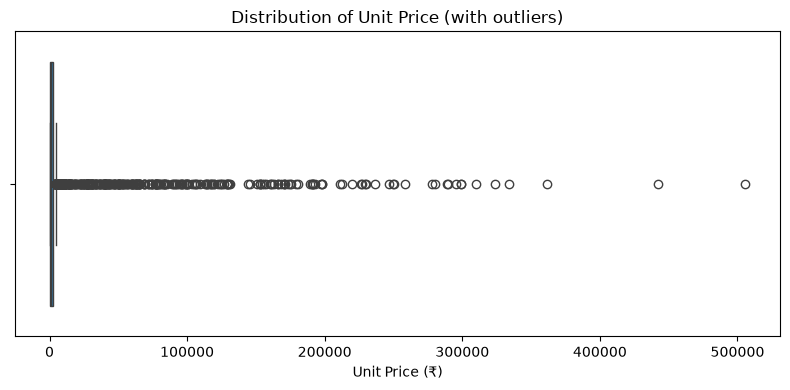

In [50]:
plt.figure(figsize=(8,4))
sns.boxplot(x=dfclean['UnitPrice'])
plt.title('Distribution of Unit Price (with outliers)')
plt.xlabel('Unit Price (₹)')
plt.tight_layout()
plt.show()

*Note: chart code below has been updated with titles/axis labels for clarity. Re-run the notebook top-to-bottom once to regenerate the images with these labels.*

**What this shows:** The boxplot makes the extreme high-price orders visible as dots far above the main cluster of prices.

###### Claude helped in outliers

*(Used AI assistance to implement the IQR outlier-flagging logic below.)*

In [51]:
Q1 = dfclean['UnitPrice'].quantile(0.25)
Q3 = dfclean['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

dfclean['is_price_outlier'] = (dfclean['UnitPrice'] < lower) | (dfclean['UnitPrice'] > upper)
dfclean['is_price_outlier'].sum()

np.int64(1164)

**Approach:** Calculate the IQR (difference between the 75th and 25th percentile) and flag any `UnitPrice` that falls far outside that range as an outlier, in a new `is_price_outlier` column.
**Result:** 1,164 orders flagged as price outliers.

In [52]:
# Full picture, outliers included
dfclean['UnitPrice'].mean()

np.float64(2892.2634100965406)

In [53]:
# "Typical" picture, outliers excluded
dfclean[~dfclean['is_price_outlier']]['UnitPrice'].mean()

np.float64(1397.2872302926726)

- `Including outliers, average UnitPrice is ₹2,892 — but excluding the flagged high-value orders, it drops to ₹1,397. The full average is more than double the typical order value, showing a small number of extreme orders significantly skew the overall picture.`

## Step 6: Feature Engineering
**Problem:** The raw columns don't directly support the kind of grouped analysis we want to do (e.g. revenue by month, or by city tier, or by age group).
**Approach:** Create a few new helper columns derived from existing ones, to make grouping and comparison easier in the EDA step.

##### Feature Engineering

In [54]:
dfclean.head()

,OrderID,CustomerID,CustomerName,Age,City,Email,Department,OrderDate,ProductCategory,PaymentMode,OrderStatus,UnitPrice,Quantity,DiscountPct,Revenue,Rating,IsReturningCustomer,is_price_outlier
0,ORD510665,CUST110665,Ananya Iyer,60.0,Kolkata,ananya.iyer@gmail.com,Not Applicable,2025-02-05,Electronics,UPI,Pending,152.91,3.0,15,389.92,1.0,False,False
1,ORD513381,CUST113381,Pooja Gupta,39.0,Bangalore,NaN,Not Applicable,2023-03-11,Groceries,COD,Pending,115.33,3.0,0,345.99,3.0,False,False
2,ORD501844,CUST101844,Sourav Trivedi,31.0,Gurgaon,sourav.trivedi@gmail.com,Finance,2025-05-20,Apparel,COD,Cancelled,2109.53,1.0,5,2004.05,4.0,False,False
3,ORD501144,CUST101144,Anjali Pillai,55.0,Noida,anjali.pillai@yahoo.com,HR,2025-07-11,Electronics,COD,Cancelled,357.10,1.0,5,339.24,2.0,False,False
4,ORD516008,CUST116008,Deepak Roy,33.0,Bangalore,deepak.roy@gmail.com,Support,2022-06-28,Books,UPI,Returned,773.26,3.0,0,2319.78,5.0,True,False


In [55]:
dfclean['OrderMonth']=dfclean['OrderDate'].dt.month
dfclean['OrderYear']=dfclean['OrderDate'].dt.year

**Approach:** Extract `OrderMonth` and `OrderYear` from `OrderDate`, so revenue trends can be grouped by month/year later.

In [56]:
tier1 = ['Mumbai','Delhi','Bangalore','Chennai','Kolkata','Hyderabad','Pune']
dfclean['CityTier'] = np.where(dfclean['City'].isin(tier1), 'Tier 1', 'Tier 2')

**Approach:** Group cities into `Tier 1` (major metros) vs `Tier 2` (others), to compare revenue between big and smaller cities.

In [57]:
dfclean['AgeGroup'] = pd.cut(dfclean['Age'], bins=[0,25,35,45,55,100], labels=['18-25','26-35','36-45','46-55','56+'])

**Approach:** Bucket customers into age groups (18-25, 26-35, etc.) so we can compare buying behavior across age ranges instead of looking at every individual age.

## Step 7: Exploratory Data Analysis (EDA)
**Problem:** Now that the data is clean, we need to actually understand it - what does the typical order look like, and how do revenue and other metrics vary across products, cities, and customers?
**Approach:** Explore step by step  first one variable at a time (univariate), then two variables together (bivariate), then three or more (multivariate).

#### EDA

<span style="font=20px"> `Univariate Analysis`</span>

- <span style="font=20px"> Histogram (histplot) for continuous numeric data with a spread

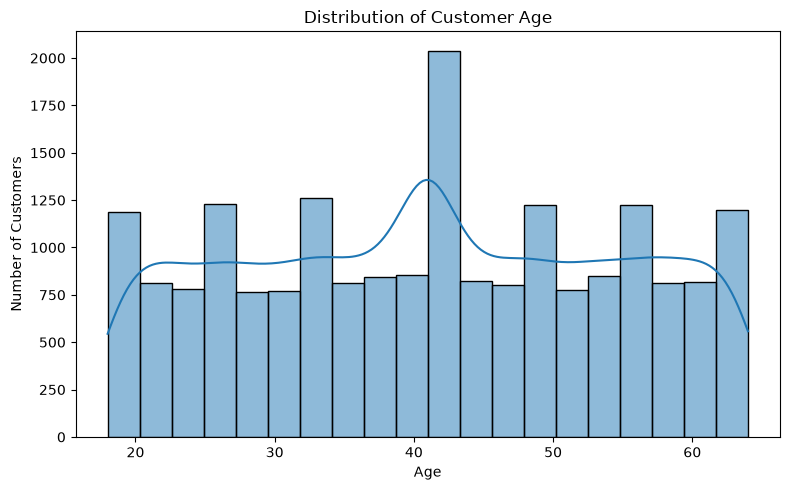

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(dfclean['Age'],bins=20,kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**What this shows:** The distribution of customer ages — helps us see which age groups are most common among buyers.

- <span style="font=20px"> Boxplot (boxplot) - for continuous numeric data when you care about spread/outliers specifically

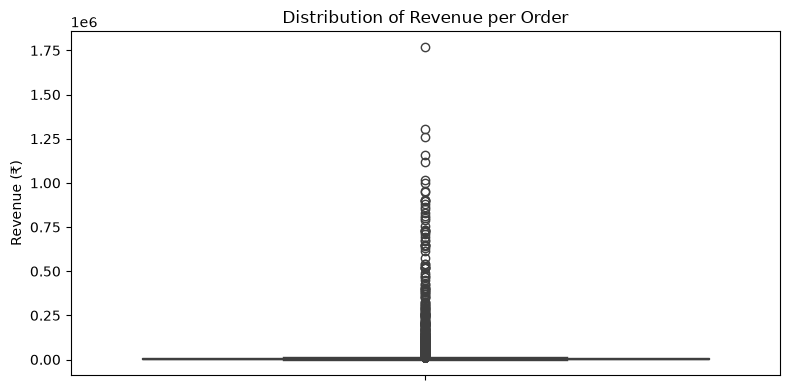

In [59]:
plt.figure(figsize=(8,4))
sns.boxplot(dfclean['Revenue'])
plt.title('Distribution of Revenue per Order')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

**What this shows:** The spread of `Revenue` per order, and how many high-value orders (outliers) sit above the typical range.

- <span style="font=20px"> Countplot (countplot) - for categorical data

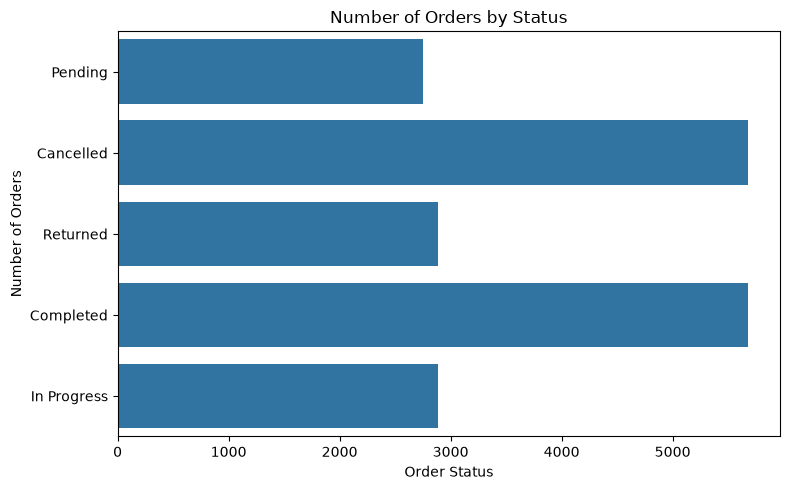

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(dfclean['OrderStatus'])
plt.title('Number of Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**What this shows:** How many orders fall into each `OrderStatus` (Completed, Cancelled, Pending, etc.) — useful for spotting if cancellations/returns are unusually high.

#### Bivariate Analysis

**Problem:** Looking at one column at a time doesn't show relationships — e.g. which product categories or cities actually drive the most revenue.
**Approach:** Group revenue by category and by city, and compare them visually.

In [61]:
revproduct=dfclean.groupby(['ProductCategory'],as_index=False)['Revenue'].sum()

**Approach:** Add up total `Revenue` for each `ProductCategory`.

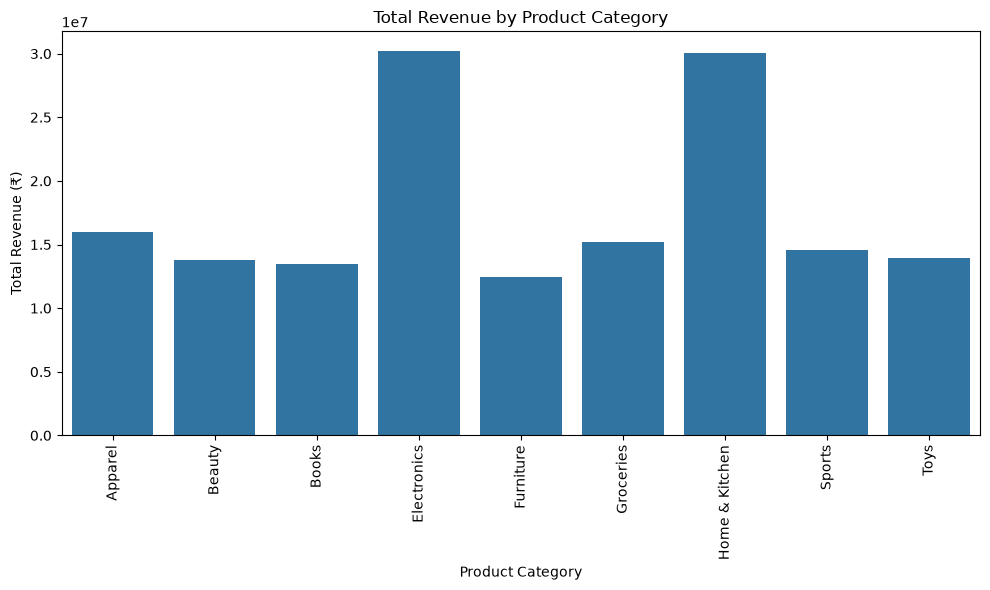

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(x='ProductCategory',y='Revenue',data=revproduct)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**What this shows:** Which product categories bring in the most vs. least total revenue useful for deciding where to focus inventory or marketing.

In [63]:
revcity=dfclean.groupby(['City'],as_index=False)['Revenue'].sum()

**Approach:** Add up total `Revenue` for each `City`.

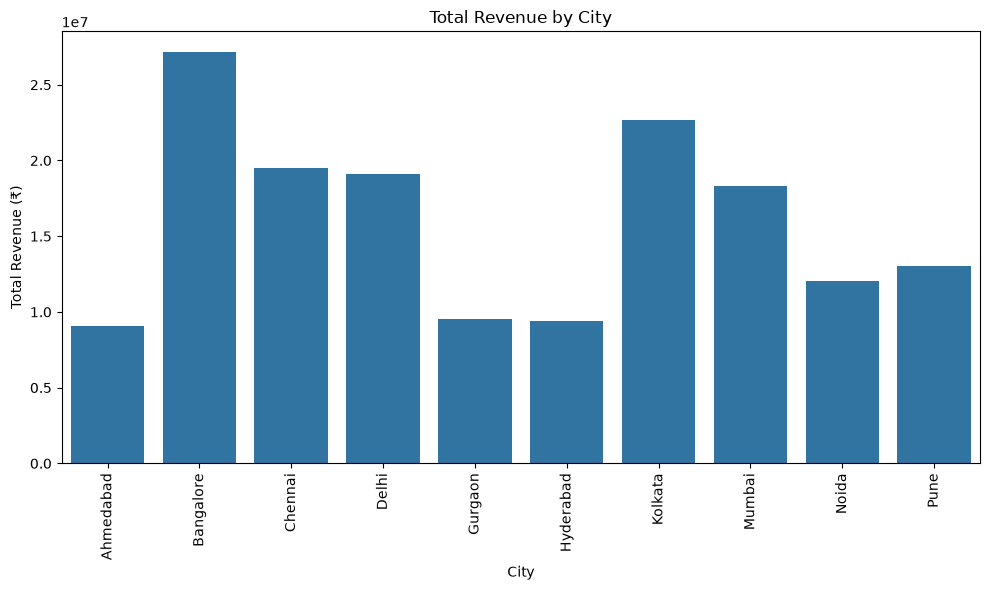

In [64]:
plt.figure(figsize=(10,6))
sns.barplot(x='City',y='Revenue',data=revcity)
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**What this shows:** Which cities generate the most revenue useful for prioritizing regional expansion or marketing spend.

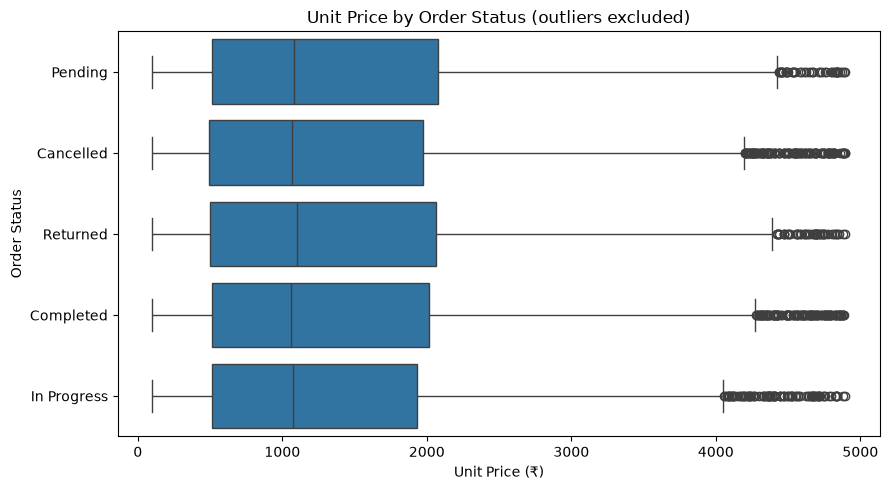

In [65]:
plt.figure(figsize=(9,5))
sns.boxplot(x='UnitPrice', y='OrderStatus', data=dfclean[~dfclean['is_price_outlier']])
plt.title('Unit Price by Order Status (outliers excluded)')
plt.xlabel('Unit Price (₹)')
plt.ylabel('Order Status')
plt.tight_layout()
plt.show()

**What this shows:** How `UnitPrice` (excluding outliers) varies across different `OrderStatus` values e.g. whether more expensive orders are more likely to get cancelled or returned.

## Correlation Check
**Problem:** We've looked at columns mostly one at a time but do any numeric columns actually move together? E.g. does a higher `DiscountPct` lead to higher `Quantity` bought, or does `Rating` relate to `Revenue`?
**Approach:** Use a correlation heatmap to check how strongly numeric columns are related (values close to 1 or -1 = strong relationship, close to 0 = no relationship).

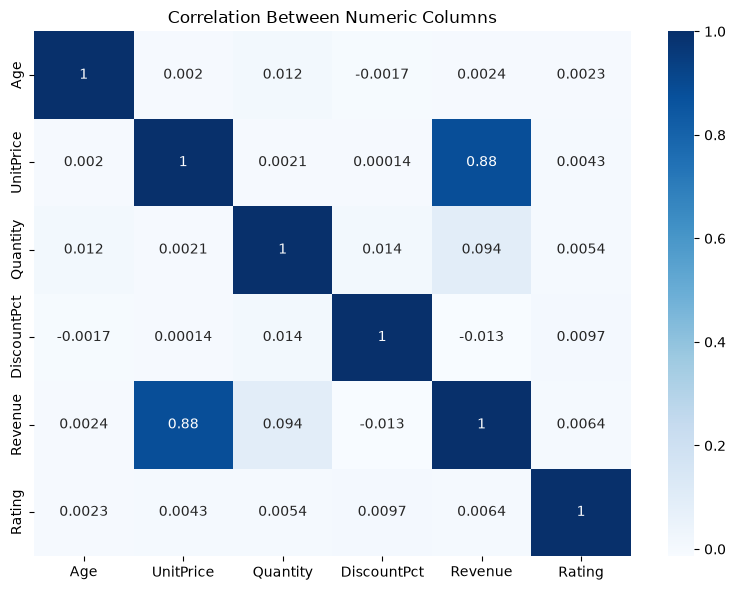

In [66]:
plt.figure(figsize=(8,6))
corr=(dfclean[['Age','UnitPrice','Quantity','DiscountPct','Revenue','Rating']].corr(numeric_only=True))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Between Numeric Columns')
plt.tight_layout()
plt.show()

**What to look for:** Values near 0 mean the two columns barely affect each other; values closer to ±1 mean a real relationship. Since `Revenue` is calculated directly from `UnitPrice`, `Quantity`, and `DiscountPct`, expect it to correlate with those by definition - the more interesting question is whether `Rating` correlates with anything, since that would suggest satisfaction is linked to price or discount level.

## Rating vs. Order Outcomes
**Problem:** We cleaned the `Rating` column but never actually used it in any chart - it's worth checking whether low ratings connect to cancelled/returned orders, or to returning customers.
**Approach:** Compare average `Rating` across `OrderStatus`, and across `IsReturningCustomer`.

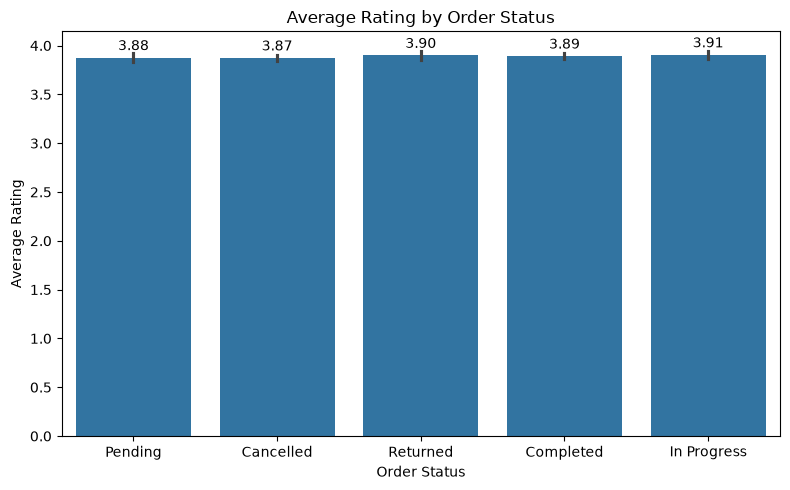

In [67]:
plt.figure(figsize=(8,5))
val=sns.barplot(x='OrderStatus', y='Rating', data=dfclean)
val.bar_label(val.containers[0], fmt='%.2f', padding=3)
plt.title('Average Rating by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

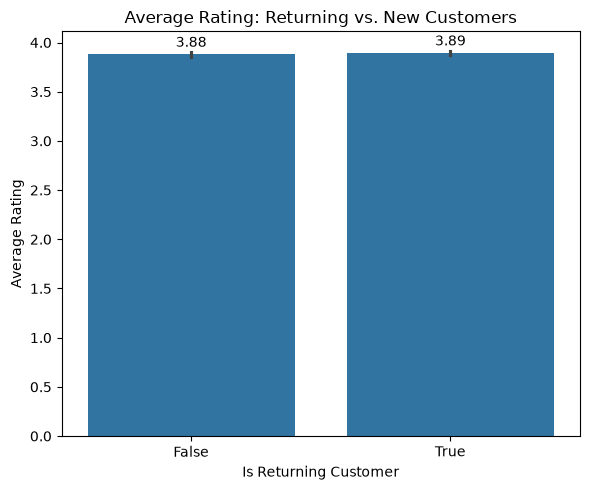

In [68]:
plt.figure(figsize=(6,5))
ax = sns.barplot(x='IsReturningCustomer', y='Rating', data=dfclean)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Average Rating: Returning vs. New Customers')
plt.xlabel('Is Returning Customer')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

**What to look for:** If `Returned`/`Cancelled` orders show a noticeably lower average rating than `Completed` orders, that's a natural, expected pattern. If returning customers rate noticeably higher than new customers, that's a sign loyal customers are more satisfied worth highlighting as a business insight.

## Multivariate Analysis
**Problem:** Revenue by category alone doesn't show *who* is buying what different age groups might prefer different product categories.
**Approach:** Combine `ProductCategory`, `AgeGroup`, and `Revenue` together in one chart to spot these patterns.

#### Multivariate Analysis

In [69]:
agegrouprev=dfclean.groupby(['ProductCategory','AgeGroup'],as_index=False)['Revenue'].sum()

**Approach:** Add up total `Revenue` for every combination of `ProductCategory` and `AgeGroup`.

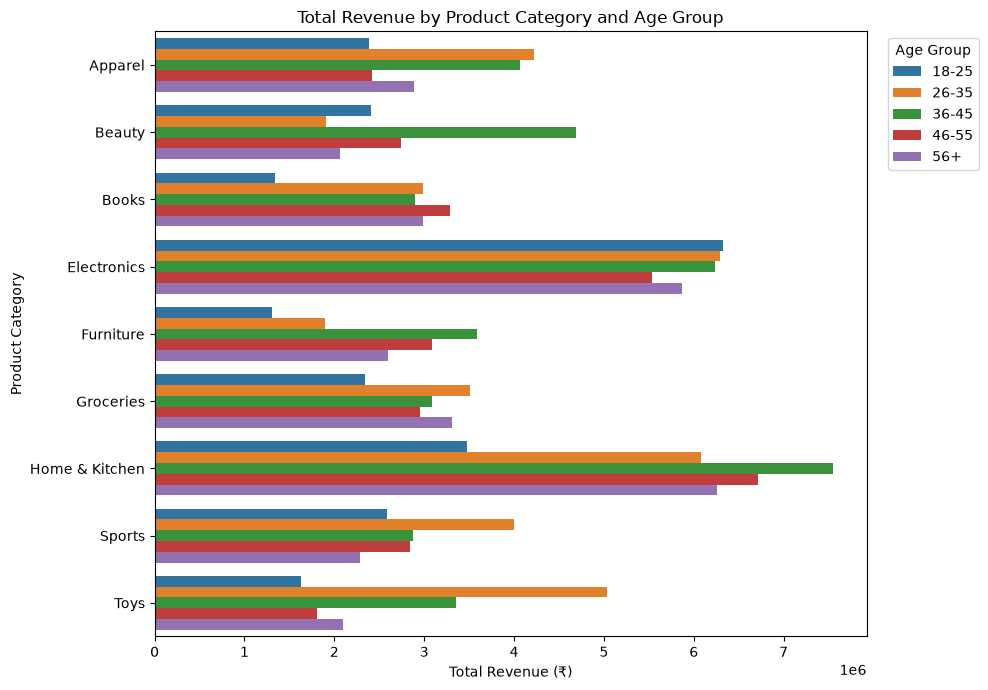

In [70]:
plt.figure(figsize=(10,7))
sns.barplot(y='ProductCategory',x='Revenue',hue='AgeGroup',data=agegrouprev)
plt.title('Total Revenue by Product Category and Age Group')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('Product Category')
plt.legend(title='Age Group', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**What this shows:** Which age groups drive the most revenue within each product category — useful for targeting marketing by both age and product type.

## Step 8: Save the Cleaned Dataset
**Approach:** Export the fully cleaned DataFrame to a new CSV file, so it can be reused for further analysis (e.g. in Power BI) without repeating the cleaning steps.

In [71]:
dfclean.to_csv('StartupSalesCleaned.csv',index=False)

## Summary

**What we did:**
- Fixed inconsistent category labels across `City`, `Department`, `ProductCategory`, `PaymentMode`, and `OrderStatus`
- Corrected wrong data types (`UnitPrice`, `DiscountPct`, `OrderDate`) and invalid values (`Age`, `Rating`, negative prices)
- Standardized `CustomerID` formatting
- Filled missing values using a method appropriate to each column (median, mode, or a placeholder label)
- Removed 512 duplicate rows (400 exact duplicates + 112 duplicate `OrderID`s)
- Flagged 1,164 price outliers using the IQR method, without deleting them
- Engineered new features (`OrderMonth`, `OrderYear`, `CityTier`, `AgeGroup`) to support grouped analysis
- Explored the data through univariate, bivariate, and multivariate analysis to understand revenue patterns across products, cities, and age groups

**Final dataset:** 19,888 clean rows, saved to `StartupSalesCleaned.csv`, ready for further analysis or dashboarding.

## Key Findings & Recommendations

- **Top-performing product category:** Electronics and Home & Kitchen are tied for the highest total revenue (~₹3.0 crore each), well above every other category (which cluster around ₹1.2 to ₹1.6 crore)
- **Top-performing city:** Bangalore generated the highest total revenue (~₹2.7 crore), followed by Kolkata (~₹2.25 crore)
- **Order outcomes:** Completed orders make up ~28.7% of all orders; Cancelled + Returned together make up ~43% of all orders. Nearly half of all orders don't end in a normal completed state
- **Price vs. cancellations:** Based on the "Unit Price by Order Status" chart, higher priced orders are not more likely to be cancelled or returned. The price distribution looks similar across all order statuses
- **Age group insight:** The 36 to 45 age group contributes the most revenue overall, and prefers Home & Kitchen as a category
- **Rating insight:** Average rating is essentially flat across all order statuses (~3.85 to 3.9) and between returning vs. new customers (~3.88 vs ~3.89). Rating does not appear tied to whether an order was completed, cancelled, or returned, nor to customer loyalty. This is actually a useful negative finding: it suggests dissatisfaction isn't the main driver of cancellations. Something else is (delivery issues, payment friction, changed mind, etc., worth investigating with more data)
- **Correlation check:** `Revenue` correlates strongly with `UnitPrice` (0.88), which makes sense since Revenue is calculated directly from it. `Quantity` has only a weak link to Revenue (0.09). `Rating`, `Age`, and `DiscountPct` show essentially no correlation (~0.00 to 0.01) with anything else. Discounting isn't meaningfully driving order size or satisfaction
- **Outliers:** 1,164 orders were flagged as unusually high priced (not removed). Worth a follow up check on whether these are bulk/B2B orders or data errors

**One clear recommendation:** Given Electronics and Home & Kitchen drive the most revenue and Bangalore is the top city, marketing and inventory focus should prioritize these. But the near 43% cancel/return rate is the bigger red flag here. Since it's clearly not explained by price or rating, the next investigation should look at delivery time, payment mode, or order timing data (if available) to find the actual driver.

## Limitations
- This is a synthetic/practice dataset, so patterns here (e.g. flat ratings, revenue by city) may not reflect real seasonal trends, real customer behavior, or real market dynamics.
- `Email` (412 missing) and `Rating` (2,379 missing) were left unimputed rather than filled, since guessing these values could bias any analysis built on them — but this does mean averages involving `Rating` are based on a slightly smaller sample than the full dataset.
- Outliers in `UnitPrice`/`Revenue` were flagged but not removed, so summary statistics like the overall mean are still somewhat pulled upward by a small number of extreme orders (as shown in the "with vs without outliers" comparison earlier).
- The cancel/return rate investigation (payment mode, city) is exploratory — a real root-cause analysis would need additional data not present here, like delivery timestamps, customer service logs, or refund reasons.